# `kamo.scattering` — K39 s-wave scattering lengths $a(B)$

Complex s-wave scattering length $a(B) = a_\mathrm{re} - i\,a_\mathrm{im}$ for two
$^{39}$K $4S_{1/2}$ atoms in any pair of Zeeman states, vs magnetic field.

**What this notebook shows**

1. The **literature resonance database** (`kamo.scattering.data.k39_feshbach`): measured
   Feshbach resonance positions, zero crossings and dimer energies from Etrych 2023,
   Chapurin 2019, Roy 2013, D'Errico 2007, Tanzi 2018, Tiemann 2020 and others.
2. The **coupled-channels** engine on the Falke 2008 K$_2$ potentials, with the
   short-range walls **calibrated to those measured positions**.
3. A comparison of both engines with the **Kokkelmans coupled-channels reference** on the
   Tweezers `G:` shared drive (8 intra-state channels, real and imaginary parts).
4. Inter-state channels, the $|1,-1\rangle/|1,0\rangle$ system, and how to use the API.

Two engines, one database:

| backend | what | speed | channels |
|---|---|---|---|
| `"empirical"` | sum of measured poles + smooth background | µs | 6 with measured resonances |
| `"cc"` | coupled channels, calibrated Falke/Tiemann curves | ~60 ms / field | any (intra, inter, F=2, lossy) |

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from kamo.scattering import ScatteringModel, CoupledChannels, find_features, locate_pole, characterize
from kamo.scattering.thresholds import K39Thresholds
from kamo.scattering.data import k39_feshbach as kf, k39_params as kp, k39_calibration as kc

# reference chart palette (fixed categorical order) + recessive chrome.
# Set after the kamo imports, which apply their own matplotlib style.
PAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
REF, MUTED = '#52514e', '#898781'           # Kokkelmans reference / annotations in neutral ink
plt.rcParams.update({
    'figure.dpi': 110, 'font.family': 'sans-serif', 'font.sans-serif': ['DejaVu Sans'],
    'mathtext.fontset': 'dejavusans', 'font.size': 9,
    'legend.fontsize': 'small', 'legend.frameon': False, 'axes.titlesize': 'medium',
    'axes.grid': True, 'grid.color': '#e1e0d9', 'grid.linewidth': 0.6,
    'axes.edgecolor': '#c3c2b7', 'axes.labelcolor': '#0b0b0b',
    'xtick.color': '#52514e', 'ytick.color': '#52514e', 'lines.linewidth': 1.4,
    'xtick.direction': 'out', 'ytick.direction': 'out', 'xtick.top': False, 'ytick.right': False,
    'xtick.minor.visible': False, 'ytick.minor.visible': False,
    'axes.spines.top': False, 'axes.spines.right': False,
})
pd.set_option('display.width', 200)

th = K39Thresholds(B_max_gauss=1000.0, dB_gauss=0.05)        # shared Zeeman thresholds
emp = ScatteringModel(B_max=1000.0)                           # empirical backend
cc = CoupledChannels(thresholds=th)                           # calibrated coupled channels (default)
cc_bare = CoupledChannels(thresholds=th, delta_S=0.0, delta_T=0.0)   # Falke 2008 curves as published

def ket(s):                                  # mathtext, for plot labels
    return rf"|{s[0]},{s[1]:+d}\rangle"

def pket(s):                                 # plain text, for printed tables
    return f"|{s[0]},{s[1]:+d}>"

def lbl(a, b=None):
    b = a if b is None else b
    return rf"${ket(a)}+{ket(b)}$"

def mask_poles(a, cap=600.0):
    a = np.array(a, dtype=float)
    a[np.abs(a) > cap] = np.nan              # break the line across poles
    return a

print(f"calibrated: a_S = {kc.A_SINGLET:.3f}({kc.A_SINGLET_UNC*1e3:.0f}) a0, "
      f"a_T = {kc.A_TRIPLET:.3f}({kc.A_TRIPLET_UNC*1e3:.0f}) a0   [chi2/dof = {kc.CHI2/kc.DOF:.2f}]")

calibrated: a_S = 138.715(5) a0, a_T = -33.387(11) a0   [chi2/dof = 0.58]


In [2]:
# Kokkelmans coupled-channels reference: 2000 fields, 1-1000 G, columns a_re, a_im,
# sigma_el, sigma_inel.  kamo reads it from the Tweezers shared drive (lookup.KOKKELMANS_DIRS).
from kamo.scattering.lookup import kokkelmans_table, kokkelmans_dir, KOKKELMANS_CITATION

KOK_STATES = [(1, 1), (1, 0), (1, -1), (2, -2), (2, -1), (2, 0), (2, 1), (2, 2)]
try:
    KOK = {s: kokkelmans_table(s)[:3] for s in KOK_STATES}     # (B, a_re, a_im)
    KOK_OK = True
    print("Kokkelmans reference loaded from", kokkelmans_dir())
    print("Citation:", KOKKELMANS_CITATION)
except FileNotFoundError as e:
    KOK_OK = False
    print("Kokkelmans reference unavailable -- comparison cells will skip:", e)

Kokkelmans reference loaded from G:/Shared drives/Tweezers/Calculations/Kokkelmans Feshbach data/K39_WideScans
Citation: S. J. J. M. F. Kokkelmans (Eindhoven University of Technology), coupled-channels calculations of 39K ground-state s-wave scattering lengths, |F,mF>+|F,mF> for F=1,2, 1-1000 G (files dated 2023-08-18), private communication to the UCSB Weld group; unpublished.  Cite as a private communication.


## 1. The literature resonance database

`kf.RESONANCES` is the best-value set: one entry per resonance, each with position and
uncertainty, provenance (table/page of the primary source) and the coupled-channels
characterisation reported with it ($\Delta$, local $a_\mathrm{bg}$, $\Gamma_\mathrm{inel}$
from Etrych's MOLSCAT). Experiments measure $B_0$, and at best the pole strength
$a_\mathrm{bg}\Delta$, not the split. Other entries:

- `ALTERNATIVE_MEASUREMENTS`: older or other measurements of the same resonances.
- `HIGHER_PARTIAL_WAVE`: d-, g- and p-wave features, outside an s-wave model.
- `ZERO_CROSSINGS`
- `DIMER_BINDING_ENERGIES_1m1`: Chapurin's 33.6 G dimer.
- `THEORY_POINTS`: other groups' CC values of $a$.
- `SINGLET_TRIPLET_LITERATURE`

In [3]:
rows = []
for r in kf.RESONANCES:
    rows.append(dict(channel=r.label, B0=r.B0, unc=r.B0_unc, source=r.source,
                     method=r.method, B0_theory=r.B0_theory, Delta=r.width_theory,
                     a_bg=r.a_bg_theory, abgDelta_meas=r.pole_strength,
                     lossy=r.lossy, fit=r.use_in_fit))
db = pd.DataFrame(rows)
print(f"{len(db)} s-wave resonances in {db.channel.nunique()} channels "
      f"({db.fit.sum()} used to calibrate the CC model);  "
      f"{len(kf.ALTERNATIVE_MEASUREMENTS)} alternative measurements, "
      f"{len(kf.HIGHER_PARTIAL_WAVE)} higher-partial-wave features, "
      f"{len(kf.ZERO_CROSSINGS)} zero crossings, {len(kf.THEORY_POINTS)} published CC points")
db

17 s-wave resonances in 6 channels (15 used to calibrate the CC model);  21 alternative measurements, 11 higher-partial-wave features, 5 zero crossings, 24 published CC points


,channel,B0,unc,source,method,B0_theory,Delta,a_bg,abgDelta_meas,lossy,fit
0,"|1,+1>+|1,+1>",25.910,0.0600,"Etrych 2023 PRR 5,013174",loss spectroscopy,25.879,-0.465,-33.10,NaN,False,True
1,"|1,+1>+|1,+1>",402.740,0.0100,"Etrych 2023 PRR 5,013174",Ramsey bound-state spectroscopy,402.554,-51.291,-29.52,1530.0,False,True
2,"|1,+1>+|1,+1>",752.300,0.1000,"D'Errico 2007 NJP 9,223",loss spectroscopy,752.255,-0.397,-35.30,NaN,False,True
3,"|1,+0>+|1,+0>",58.970,0.1200,"Etrych 2023 PRR 5,013174",loss spectroscopy,58.949,-6.648,-29.22,NaN,False,True
4,"|1,+0>+|1,+0>",65.570,0.2300,"Etrych 2023 PRR 5,013174",loss spectroscopy,65.573,-3.361,-41.87,NaN,False,True
5,"|1,+0>+|1,+0>",472.330,0.0100,"Etrych 2023 PRR 5,013174",bound-state spectroscopy,472.118,-117.780,-16.96,2040.0,False,True
6,"|1,+0>+|1,+0>",491.170,0.0700,"Etrych 2023 PRR 5,013174",loss spectroscopy,490.930,-1.045,-133.43,140.0,False,True
7,"|1,-1>+|1,-1>",33.582,0.0014,"Chapurin 2019 PRL 123,233402",dimer binding energies (tuned CC),33.568,79.469,-13.50,-1073.5,False,True
8,"|1,-1>+|1,-1>",162.360,0.0200,"Etrych 2023 PRR 5,013174",bound-state spectroscopy,162.347,-60.628,-11.73,760.0,False,True
9,"|1,-1>+|1,-1>",561.140,0.0200,"Etrych 2023 PRR 5,013174",bound-state spectroscopy,560.935,-55.358,-29.10,1660.0,False,True


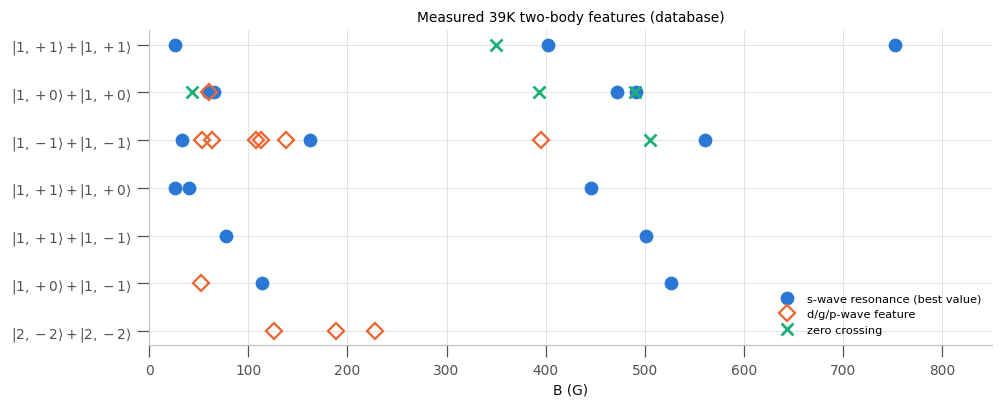

In [4]:
# resonance map: every measured feature by channel
chan_order = [((1, 1), (1, 1)), ((1, 0), (1, 0)), ((1, -1), (1, -1)), ((1, 1), (1, 0)),
              ((1, 1), (1, -1)), ((1, 0), (1, -1)), ((2, -2), (2, -2))]
keyof = lambda a, b: frozenset((tuple(a), tuple(b)))
yof = {keyof(*c): i for i, c in enumerate(chan_order)}

fig, ax = plt.subplots(figsize=(9, 3.6), layout='constrained')
def put(items, y_get, **kw):
    xs = [x for x, y in ((i[0], y_get(i)) for i in items) if y is not None]
    ys = [y for y in (y_get(i) for i in items) if y is not None]
    ax.plot(xs, ys, ls='none', **kw)
put([(r.B0, r) for r in kf.RESONANCES], lambda i: yof.get(i[1].channel),
    marker='o', ms=8, color=PAL[0], label='s-wave resonance (best value)')
put([(r.B0, r) for r in kf.HIGHER_PARTIAL_WAVE], lambda i: yof.get(i[1].channel),
    marker='D', ms=7, mfc='none', mew=1.5, color=PAL[1], label='d/g/p-wave feature')
put([(z.B_zero, z) for z in kf.ZERO_CROSSINGS], lambda i: yof.get(keyof(i[1].state_a, i[1].state_b)),
    marker='x', ms=8, mew=1.8, color=PAL[2], label='zero crossing')
ax.set_yticks(range(len(chan_order)), [lbl(*c) for c in chan_order])
ax.set(xlabel='B (G)', xlim=(0, 850), title='Measured 39K two-body features (database)')
ax.invert_yaxis()
ax.legend(loc='lower right')

## 2. The Falke 2008 potentials

The singlet X$^1\Sigma_g^+$ and triplet a$^3\Sigma_u^+$ curves are the analytic
three-region fits of Falke *et al.*, PRA 78, 012503 (2008), Tables IV/V, in
`kamo.scattering.tiemann`.

**Fixed in this revision:** four coefficients in the old transcription were wrong:
- singlet $a_{12}$ and $a_{23}$: transposed digits;
- triplet $a_1$: 10× too large;
- triplet $a_{10}$: one wrong digit.

The triplet therefore had a **47 cm$^{-1}$ step** at $R_\mathrm{out}=12$ Å. That was the
"3% transcription limit" noted before: the old $a_S = 135.4$ and $a_T = -32.4$.

With the paper's coefficients, the curves are continuous to $10^{-5}$ cm$^{-1}$. They give
$a_S$ and $a_T$ equal to Falke's Table VIII, and to an independent CC calculation on the same
curves (Laskowski & Mehta 2023).

In [5]:
from kamo.scattering import tiemann as T
for name, P in (('singlet', T.SINGLET), ('triplet', T.TRIPLET)):
    steps = [abs(T.potential_cm1(np.array([P[e] + 1e-9]), P)[0] - T.potential_cm1(np.array([P[e] - 1e-9]), P)[0])
             for e in ('Rinn', 'Rout')]
    print(f"{name}: step at R_inn / R_out = {steps[0]:.1e} / {steps[1]:.1e} cm^-1")
aS0, aT0 = cc_bare.singlet_triplet_a()
print(f"\nbare curves on the CC grid:  a_S = {aS0:.3f}  a_T = {aT0:.3f} a0")
print(f"grid-converged (h->0):       a_S = {kc.A_SINGLET_BARE:.3f}  a_T = {kc.A_TRIPLET_BARE:.3f} a0")
print("Falke 2008 Table VIII (A):   a_S = 138.80   a_T = -33.41 a0")
print("Laskowski & Mehta 2023:      a_S = 138.808  a_T = -33.391 a0")

singlet: step at R_inn / R_out = 5.5e-06 / 9.4e-06 cm^-1
triplet: step at R_inn / R_out = 7.8e-07 / 2.5e-07 cm^-1



bare curves on the CC grid:  a_S = 138.803  a_T = -33.390 a0
grid-converged (h->0):       a_S = 138.809  a_T = -33.390 a0
Falke 2008 Table VIII (A):   a_S = 138.80   a_T = -33.41 a0
Laskowski & Mehta 2023:      a_S = 138.808  a_T = -33.391 a0


## 3. Calibrating the coupled channels on measured resonance positions

The published curves leave a small uncertainty in the short-range phase of each spin
state, i.e. in $a_S$ and $a_T$. `kamo.scattering.calibration.calibrate` fits those two numbers
by adding Chapurin's inner-wall correction $\delta_{S,T}\,(r-r_\mathrm{eq})^2$ for
$r<r_\mathrm{eq}$. It minimises

$$\chi^2=\sum_j \frac{\big(B_{0,j}^\mathrm{CC}(a_S,a_T)-B_{0,j}^\mathrm{exp}\big)^2}{\sigma_{\mathrm{exp},j}^2+\sigma_\mathrm{model}^2},\qquad \sigma_\mathrm{model}=20\ \mathrm{mG},$$

over the 15 elastic s-wave resonances in 5 channels. CC pole positions are found by Brent's
method on $1/a$.

The result is stored in `kamo.scattering.data.k39_calibration` and is the default for
`CoupledChannels()`. Rerun it after changing the database; it takes about 3 min:

```python
from kamo.scattering.calibration import calibrate
res = calibrate(); print(res.summary())
```

The two lossy $|1,+1\rangle+|1,-1\rangle$ resonances are **held out** as an out-of-sample test.

      channel  B0_exp    unc  bare-exp  etrych-exp  cal-exp   fit
|1,+1>+|1,+1>  25.910 0.0600   -0.0300      -0.031  -0.0339  True
|1,+1>+|1,+1> 402.740 0.0100   -0.2371      -0.186   0.0015  True
|1,+1>+|1,+1> 752.300 0.1000   -0.0126      -0.045  -0.0134  True
|1,+0>+|1,+0>  58.970 0.1200   -0.1578      -0.021  -0.1355  True
|1,+0>+|1,+0>  65.570 0.2300    0.0072       0.003   0.0071  True
|1,+0>+|1,+0> 472.330 0.0100   -0.2647      -0.212  -0.0169  True
|1,+0>+|1,+0> 491.170 0.0700   -0.2847      -0.240  -0.0611  True
|1,-1>+|1,-1>  33.582 0.0014   -0.0046      -0.014  -0.0174  True
|1,-1>+|1,-1> 162.360 0.0200   -0.0198      -0.013  -0.0120  True
|1,-1>+|1,-1> 561.140 0.0200   -0.2626      -0.205  -0.0148  True
|1,+1>+|1,+0>  25.810 0.0600   -0.0302      -0.025  -0.0338  True
|1,+1>+|1,+0>  39.810 0.0600    0.0266       0.025   0.0228  True
|1,+1>+|1,+0> 445.420 0.0300   -0.1757      -0.127   0.0587  True
|1,+1>+|1,-1>  77.600 0.4000    0.1151       0.125   0.1450 False
|1,+1>+|1,

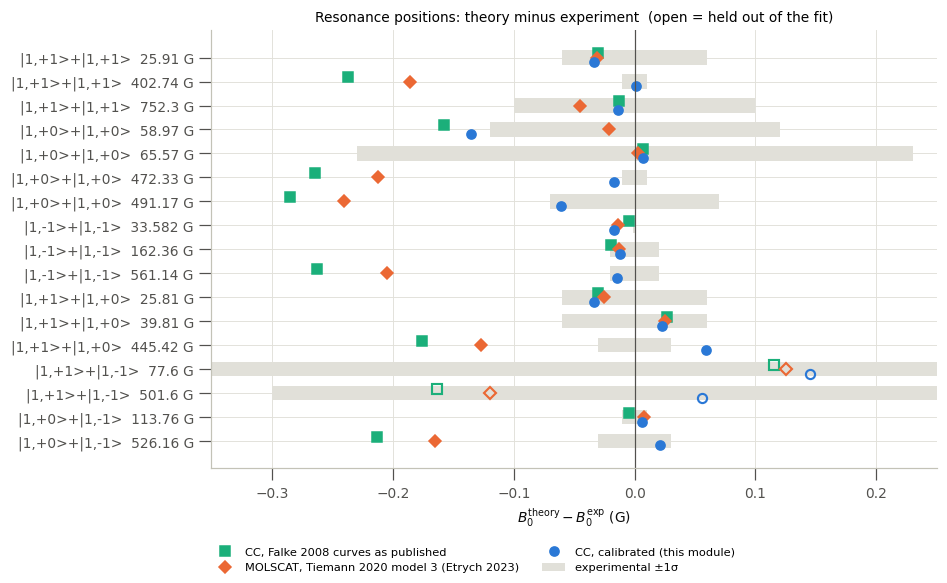

In [6]:
P = pd.DataFrame(kc.POSITIONS, columns=['channel', 'a', 'b', 'B0_exp', 'unc', 'B0_bare',
                                        'B0_cal', 'B0_etrych', 'fit', 'source'])
P['bare-exp'] = P.B0_bare - P.B0_exp
P['etrych-exp'] = P.B0_etrych - P.B0_exp
P['cal-exp'] = P.B0_cal - P.B0_exp
names = [f"{lab}  {b0:g} G" for lab, b0 in zip(P.channel, P.B0_exp)]
y = np.arange(len(P))

fig, ax = plt.subplots(figsize=(8.5, 5.2), layout='constrained')
ax.barh(y, 2 * P.unc, left=-P.unc, height=0.6, color='#e1e0d9', label='experimental ±1σ')
series = [('bare-exp', 'CC, Falke 2008 curves as published', PAL[2], 's'),
          ('etrych-exp', 'MOLSCAT, Tiemann 2020 model 3 (Etrych 2023)', PAL[1], 'D'),
          ('cal-exp', 'CC, calibrated (this module)', PAL[0], 'o')]
for k, (col, name, c, m) in enumerate(series):
    fit = P.fit.values
    ax.plot(P[col][fit], y[fit] + (k - 1) * 0.18, m, color=c, ms=6, label=name)
    ax.plot(P[col][~fit], y[~fit] + (k - 1) * 0.18, m, color=c, ms=6, mfc='none', mew=1.4)
ax.axvline(0, color=REF, lw=0.8)
ax.set_yticks(y, names)
ax.invert_yaxis()
ax.set(xlabel=r'$B_0^\mathrm{theory} - B_0^\mathrm{exp}$ (G)', xlim=(-0.35, 0.25),
       title='Resonance positions: theory minus experiment  (open = held out of the fit)')
fig.legend(loc='outside lower center', ncols=2)
print(P[['channel', 'B0_exp', 'unc', 'bare-exp', 'etrych-exp', 'cal-exp', 'fit']].round(4).to_string(index=False))

Both published-potential calculations are **low for every resonance between 400 and 560 G**,
while agreeing at low field: ours on the Falke curves by 0.16–0.29 G, and Etrych's MOLSCAT
on Tiemann 2020 by 0.12–0.24 G. The calibration removes this with a
$-0.09\,a_0$ shift of $a_S$. After it, all 15 fitted positions agree within 0.07 G, except
58.97 G (−0.14 G, 1.1σ). That resonance has a d-wave neighbour at 60.1 G that an s-wave model
omits. The held-out lossy resonances (77.6 and 501.6 G) land within 0.4σ.

Text(0.5, 1.0, 'triplet')

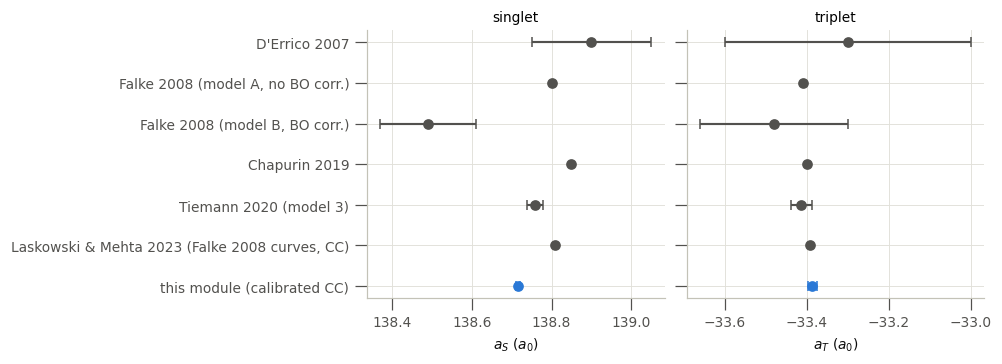

In [7]:
lit = dict(kf.SINGLET_TRIPLET_LITERATURE)
lit['this module (calibrated CC)'] = (kc.A_SINGLET, kc.A_SINGLET_UNC, kc.A_TRIPLET, kc.A_TRIPLET_UNC)
names = list(lit)
fig, axs = plt.subplots(1, 2, figsize=(9, 3.2), layout='constrained', sharey=True)
for ax, (i, lab) in zip(axs, ((0, r'$a_S$ ($a_0$)'), (2, r'$a_T$ ($a_0$)'))):
    for k, n in enumerate(names):
        v, e = lit[n][i], lit[n][i + 1]
        c = PAL[0] if n.startswith('this') else REF
        ax.errorbar(v, k, xerr=e if e else None, fmt='o', color=c, ms=6, capsize=3)
    ax.set_xlabel(lab)
axs[0].set_yticks(range(len(names)), names)
axs[0].invert_yaxis()
axs[0].set_title('singlet'); axs[1].set_title('triplet')

## 4. Coupled channels vs the Kokkelmans reference: all 8 intra-state channels

The Kokkelmans data are a full coupled-channels calculation, with magnetic dipole–dipole
coupling, on 1–1000 G for $|F,m_F\rangle+|F,m_F\rangle$, $F=1,2$. The CC here is evaluated
at every 7th Kokkelmans field, so no interpolation is needed.

2288 CC evaluations in 96 s
           channel  median|dRe a|  RMS (>3 G from measured poles)
            |1,-1>       0.014      2.464  a0
            |1,+0>       0.011      1.570  a0
            |1,+1>       0.009      1.240  a0
            |2,-2>       0.008      0.050  a0
            |2,-1>       0.011      0.019  a0
            |2,+0>       0.016      0.022  a0
            |2,+1>       0.009      0.018  a0
            |2,+2>       0.003      0.016  a0


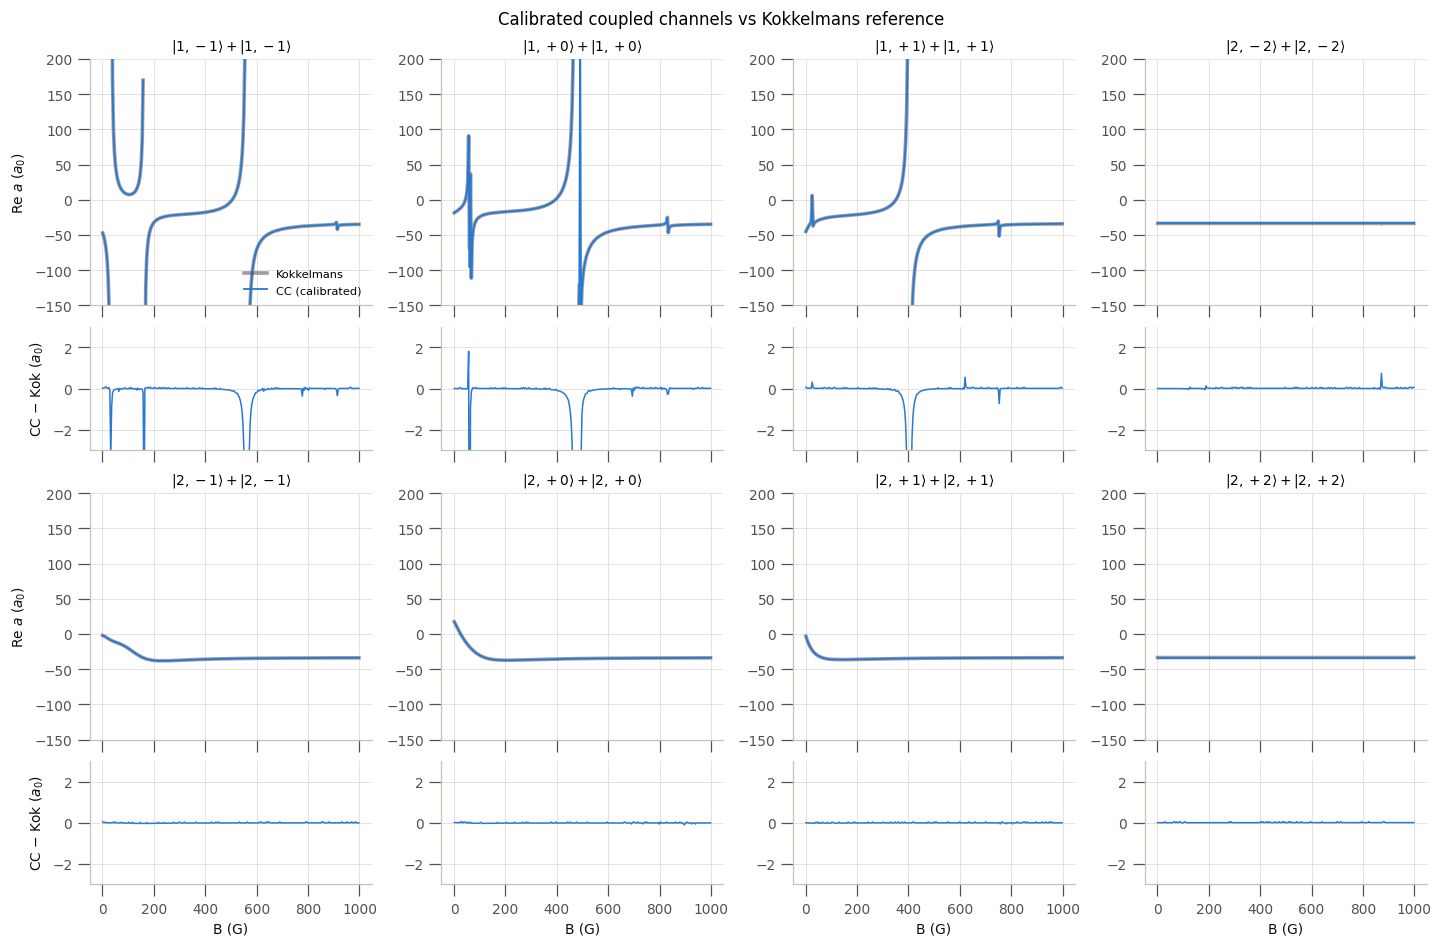

In [8]:
STATES = [(1, -1), (1, 0), (1, 1), (2, -2), (2, -1), (2, 0), (2, 1), (2, 2)]
CCK = {}
if KOK_OK:
    t0 = time.time()
    for s in STATES:
        B_k, ar_k, ai_k = KOK[s]
        idx = np.arange(0, len(B_k), 7)
        a_cc = np.array([cc.scattering_length(s, s, float(b)) for b in B_k[idx]])
        CCK[s] = (B_k[idx], a_cc, ar_k[idx], ai_k[idx])
    print(f"{sum(len(v[0]) for v in CCK.values())} CC evaluations in {time.time()-t0:.0f} s")

    fig, axs = plt.subplots(4, 4, figsize=(13, 8.5), layout='constrained', sharex=True,
                            height_ratios=[2, 1, 2, 1])
    for k, s in enumerate(STATES):
        r, c = 2 * (k // 4), k % 4
        B_, a_cc, ar, ai = CCK[s]
        axs[r, c].plot(B_, mask_poles(ar), color=REF, lw=2.4, alpha=0.55, label='Kokkelmans')
        axs[r, c].plot(B_, mask_poles(a_cc.real), color=PAL[0], lw=1.2, label='CC (calibrated)')
        axs[r, c].set(title=lbl(s), ylim=(-150, 200))
        axs[r + 1, c].plot(B_, a_cc.real - ar, color=PAL[0], lw=1.0)
        axs[r + 1, c].set(ylim=(-3, 3))
        if c == 0:
            axs[r, c].set_ylabel(r'Re $a$ ($a_0$)'); axs[r + 1, c].set_ylabel(r'CC − Kok ($a_0$)')
    axs[0, 0].legend(loc='lower right')
    for c in range(4):
        axs[3, c].set_xlabel('B (G)')
    fig.suptitle('Calibrated coupled channels vs Kokkelmans reference')

    print(f"{'channel':>18s}  median|dRe a|  RMS (>3 G from measured poles)")
    for s in STATES:
        B_, a_cc, ar, ai = CCK[s]
        poles = [r.B0 for r in kf.resonances_for(s, s)]
        m = np.all([np.abs(B_ - p) > 3 for p in poles], axis=0) if poles else np.ones_like(B_, bool)
        d = a_cc.real[m] - ar[m]
        print(f"{pket(s):>18s}  {np.median(np.abs(d)):10.3f}   {np.sqrt(np.mean(d**2)):8.3f}  a0")

Away from poles, calibrated CC and Kokkelmans differ by a **median of 0.003–0.016 $a_0$**
in every channel, including the lossy $F=2$ channels and the pure-triplet stretched states.

The larger RMS in the $F=1$ channels (1–2.5 $a_0$) comes from points a few gauss from a
resonance, where $a$ changes quickly. There the calibration has moved the poles by
0.2–0.25 G onto the measured positions (zoom below). The few narrow spikes in the residuals
are dipolar d-wave features that Kokkelmans includes and the s-wave CC does not, e.g.
$|1,+1\rangle$ near 620 G.

The spot-check table shows that the Kokkelmans reference agrees with the **bare** Falke
curves to ≲0.1 $a_0$. So it is a calculation on essentially these potentials, and its
400–560 G poles carry the same offset from experiment.

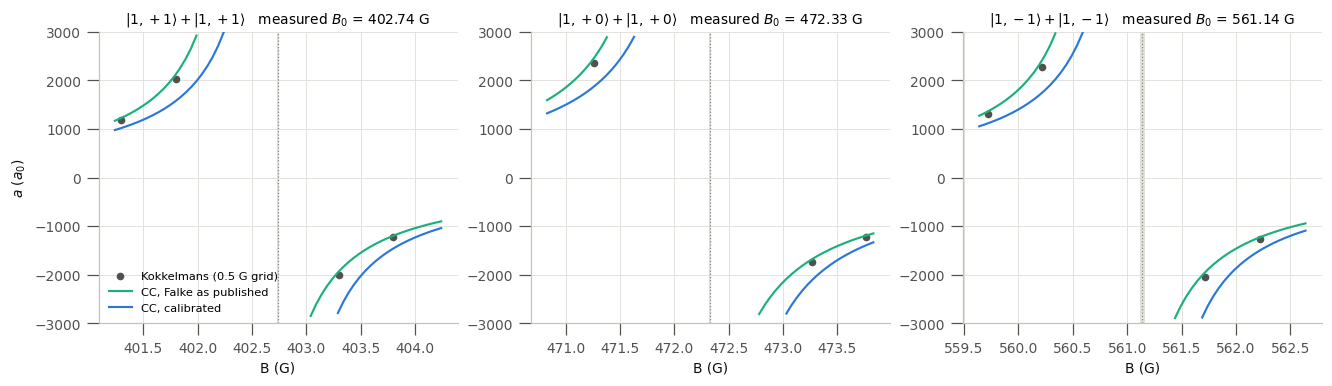

In [9]:
# the calibration shift, up close
ZOOM = [((1, 1), 402.74), ((1, 0), 472.33), ((1, -1), 561.14)]
if KOK_OK:
    fig, axs = plt.subplots(1, 3, figsize=(12, 3.4), layout='constrained')
    for ax, (s, B0) in zip(axs, ZOOM):
        Bz = np.linspace(B0 - 1.5, B0 + 1.5, 61)
        a_cal = np.array([cc.scattering_length(s, s, float(b)).real for b in Bz])
        a_bare = np.array([cc_bare.scattering_length(s, s, float(b)).real for b in Bz])
        B_k, ar_k, _ = KOK[s]
        w = (B_k > B0 - 1.5) & (B_k < B0 + 1.5)
        unc = next(r.B0_unc for r in kf.RESONANCES if r.channel == keyof(s, s) and r.B0 == B0)
        ax.axvspan(B0 - unc, B0 + unc, color='#e1e0d9', lw=0)
        ax.axvline(B0, color=MUTED, lw=0.8, ls=':')
        ax.plot(B_k[w], mask_poles(ar_k[w], 3000), 'o', color=REF, ms=4, label='Kokkelmans (0.5 G grid)')
        ax.plot(Bz, mask_poles(a_bare, 3000), color=PAL[2], label='CC, Falke as published')
        ax.plot(Bz, mask_poles(a_cal, 3000), color=PAL[0], label='CC, calibrated')
        ax.set(title=f"{lbl(s)}   measured $B_0$ = {B0} G", xlabel='B (G)', ylim=(-3000, 3000))
    axs[0].set_ylabel(r'$a$ ($a_0$)')
    axs[0].legend(loc='lower left')

In [10]:
# the Kokkelmans reference is essentially the bare Falke curves: spot check, all 8 channels
if KOK_OK:
    fields = [5., 20., 80., 150., 250., 300., 620., 900.]
    tab = {}
    for s in STATES:
        B_k, ar_k, _ = KOK[s]
        tab[pket(s)] = [cc_bare.scattering_length(s, s, b).real - np.interp(b, B_k, ar_k) for b in fields]
    diff = pd.DataFrame(tab, index=[f"{b:g} G" for b in fields]).T
    print("CC on the bare Falke 2008 curves minus Kokkelmans (a0):")
    display(diff.round(3))

CC on the bare Falke 2008 curves minus Kokkelmans (a0):


,5 G,20 G,80 G,150 G,250 G,300 G,620 G,900 G
"|1,-1>",0.063,0.051,0.005,0.021,0.002,0.001,0.048,0.000
"|1,+0>",0.060,0.009,-0.006,0.007,-0.001,0.005,0.031,0.005
"|1,+1>",0.059,0.055,0.004,0.004,0.004,0.007,-0.924,0.004
"|2,-2>",-0.003,-0.004,-0.004,0.001,0.008,0.007,0.020,0.008
"|2,-1>",-0.022,-0.035,-0.072,-0.086,-0.001,-0.033,-0.015,-0.012
"|2,+0>",-0.000,-0.022,-0.074,-0.060,-0.034,-0.029,-0.020,-0.012
"|2,+1>",-0.041,-0.011,-0.011,-0.032,-0.020,-0.018,-0.012,-0.010
"|2,+2>",-0.004,-0.004,-0.005,-0.003,-0.002,-0.002,-0.000,0.000


  |2,-1>: median |a_im(CC) - a_im(Kok)| / a_im = 0.39%   (fields with a_im > 1 a0)
  |2,+0>: median |a_im(CC) - a_im(Kok)| / a_im = 0.41%   (fields with a_im > 1 a0)
  |2,+1>: median |a_im(CC) - a_im(Kok)| / a_im = 0.59%   (fields with a_im > 1 a0)
  |1,-1>: CC a_im = 0.0e+00,  Kokkelmans max a_im = 9.7e+02 a0  (dipolar relaxation, not in the s-wave CC)
  |1,+0>: CC a_im = 0.0e+00,  Kokkelmans max a_im = 4.5e+01 a0  (dipolar relaxation, not in the s-wave CC)
  |1,+1>: CC a_im = 0.0e+00,  Kokkelmans max a_im = 6.1e+01 a0  (dipolar relaxation, not in the s-wave CC)
  |2,-2>: CC a_im = 0.0e+00,  Kokkelmans max a_im = 1.7e-01 a0  (dipolar relaxation, not in the s-wave CC)
  |2,+2>: CC a_im = 0.0e+00,  Kokkelmans max a_im = 2.2e-02 a0  (dipolar relaxation, not in the s-wave CC)


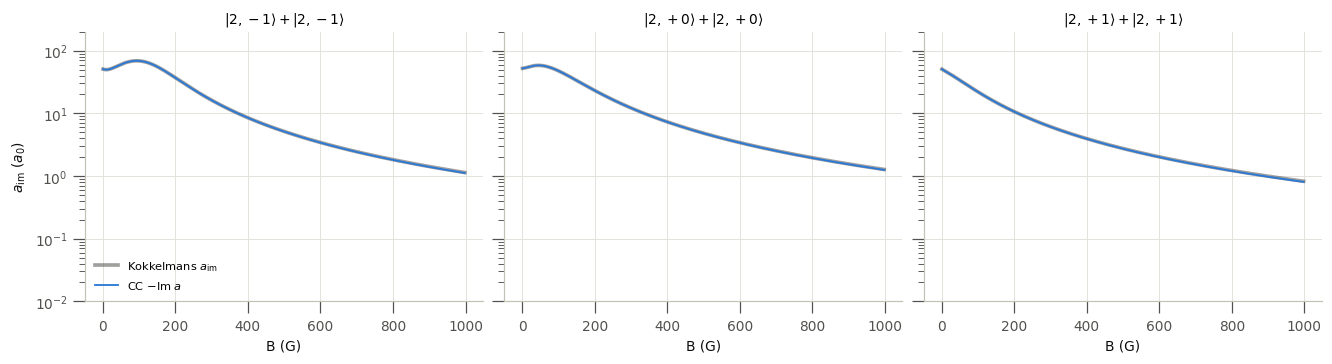

In [11]:
# imaginary part: two-body loss.  F=2 pairs spin-relax into F=1 channels.
# Kokkelmans' a_im is also nonzero (tiny) for F=1 from dipolar relaxation, not in the s-wave CC.
if KOK_OK:
    F2 = [(2, -1), (2, 0), (2, 1)]
    fig, axs = plt.subplots(1, 3, figsize=(12, 3.2), layout='constrained', sharey=True)
    for ax, s in zip(axs, F2):
        B_, a_cc, ar, ai = CCK[s]
        ax.plot(B_, ai, color=REF, lw=2.4, alpha=0.55, label='Kokkelmans $a_\\mathrm{im}$')
        ax.plot(B_, -a_cc.imag, color=PAL[0], lw=1.2, label='CC $-$Im $a$')
        ax.set(title=lbl(s), xlabel='B (G)', yscale='log', ylim=(1e-2, 200))
    axs[0].set_ylabel(r'$a_\mathrm{im}$ ($a_0$)')
    axs[0].legend(loc='lower left')
    for s in F2:
        B_, a_cc, ar, ai = CCK[s]
        m = ai > 1.0
        print(f"{pket(s):>8s}: median |a_im(CC) - a_im(Kok)| / a_im = "
              f"{np.median(np.abs(-a_cc.imag[m] - ai[m]) / ai[m]):.2%}   (fields with a_im > 1 a0)")
    for s in [(1, -1), (1, 0), (1, 1), (2, -2), (2, 2)]:
        print(f"{pket(s):>8s}: CC a_im = {np.abs(CCK[s][1].imag).max():.1e},"
              f"  Kokkelmans max a_im = {CCK[s][3].max():.1e} a0  (dipolar relaxation, not in the s-wave CC)")

## 5. Empirical backend vs Kokkelmans

The empirical backend is the analytic sum of measured poles,
$a(B) = b(B) - \sum_i s_i/(B-B_{0,i})$. It uses the measured $B_{0,i}$, the pole strengths
$s_i = a_{\mathrm{bg},i}\Delta_i$ (measured where reported), and a smooth background $b(B)$
anchored at the poles and at the measured zero crossings. It is instant, and exact at the
measured positions and zero crossings. Its background is linear between anchors, so far
from them it drifts: $|1,+1\rangle$ at 50–300 G by up to ~6 $a_0$, and between the strongly
overlapping $|1,0\rangle$ pair at 59/66 G. Use the CC where that matters.

  |1,-1>: RMS(empirical - Kokkelmans) >3 G from poles = 2.91 a0, median 0.70 a0
  |1,+0>: RMS(empirical - Kokkelmans) >3 G from poles = 2.68 a0, median 1.31 a0
  |1,+1>: RMS(empirical - Kokkelmans) >3 G from poles = 3.08 a0, median 0.34 a0


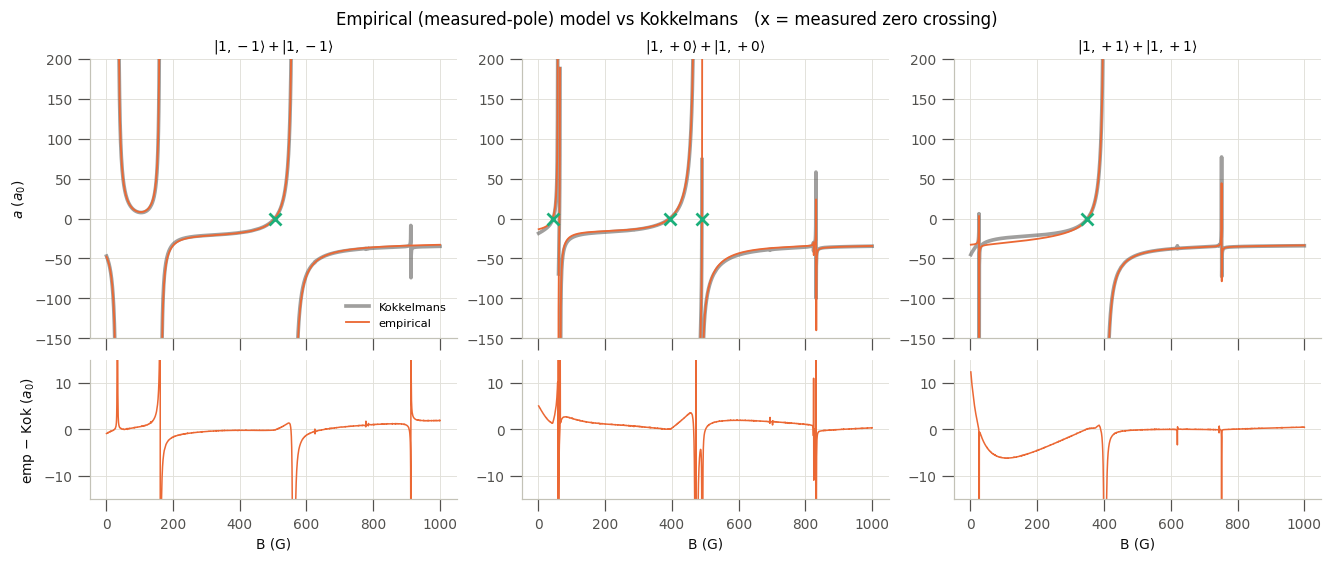

In [12]:
if KOK_OK:
    fig, axs = plt.subplots(2, 3, figsize=(12, 5), layout='constrained', sharex=True, height_ratios=[2, 1])
    for c, s in enumerate([(1, -1), (1, 0), (1, 1)]):
        B_k, ar_k, _ = KOK[s]
        a_e = emp.intra(s, B_k)
        axs[0, c].plot(B_k, mask_poles(ar_k), color=REF, lw=2.4, alpha=0.55, label='Kokkelmans')
        axs[0, c].plot(B_k, mask_poles(a_e), color=PAL[1], lw=1.2, label='empirical')
        for z in emp.zero_crossings(s, s):
            axs[0, c].plot(z, 0, 'x', color=PAL[2], ms=8, mew=1.8)
        axs[0, c].set(title=lbl(s), ylim=(-150, 200))
        axs[1, c].plot(B_k, a_e - ar_k, color=PAL[1], lw=1.0)
        axs[1, c].set(ylim=(-15, 15), xlabel='B (G)')
        poles = [r.B0_gauss for r in emp.resonances(s, s)]
        m = np.all([np.abs(B_k - p) > 3 for p in poles], axis=0)
        d = a_e[m] - ar_k[m]
        print(f"{pket(s):>8s}: RMS(empirical - Kokkelmans) >3 G from poles = {np.sqrt(np.mean(d**2)):.2f} a0,"
              f" median {np.median(np.abs(d)):.2f} a0")
    axs[0, 0].set_ylabel(r'$a$ ($a_0$)'); axs[1, 0].set_ylabel(r'emp − Kok ($a_0$)')
    axs[0, 0].legend(loc='lower right')
    fig.suptitle('Empirical (measured-pole) model vs Kokkelmans   (x = measured zero crossing)')

## 6. Inter-state channels

Kokkelmans provides no inter-state $a(B)$ table; the data folder has only $K_2$ plots. The
checks here are the measured resonance positions (grey lines) and other groups' published CC
values (black squares): Lavoine 2021, Hammond 2022 and Eid 2025 on Tiemann 2020 potentials,
and Sanz 2022 and Frölian 2022 on Roy 2013.

CC inter-state sweep: 39 s


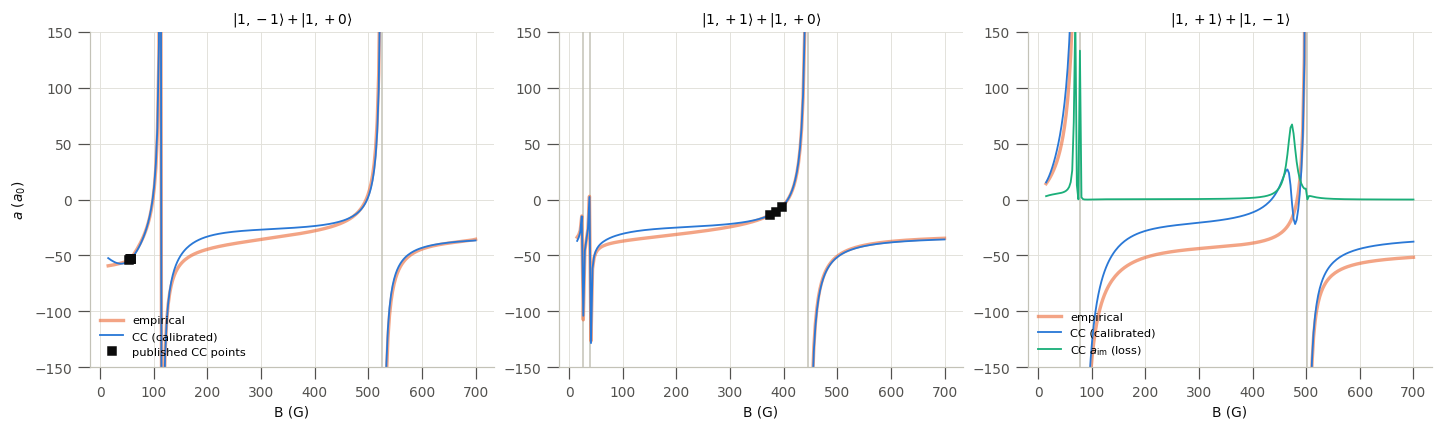

In [13]:
INTER = [((1, -1), (1, 0)), ((1, 1), (1, 0)), ((1, 1), (1, -1))]
Bi = np.linspace(15, 700, 240)
t0 = time.time()
A_INTER = {c: np.array([cc.scattering_length(*c, float(b)) for b in Bi]) for c in INTER}
print(f"CC inter-state sweep: {time.time()-t0:.0f} s")

fig, axs = plt.subplots(1, 3, figsize=(13, 3.8), layout='constrained')
for ax, c in zip(axs, INTER):
    for r in kf.resonances_for(*c):
        ax.axvline(r.B0, color='#c3c2b7', lw=1.0)
    a_c = A_INTER[c]
    ax.plot(Bi, mask_poles(emp.inter(*c, Bi).real), color=PAL[1], lw=2.2, alpha=0.6, label='empirical')
    ax.plot(Bi, mask_poles(a_c.real), color=PAL[0], lw=1.2, label='CC (calibrated)')
    if np.any(a_c.imag < -1e-6):
        ax.plot(Bi, -a_c.imag, color=PAL[2], lw=1.2, label=r'CC $a_\mathrm{im}$ (loss)')
    pts = [p for p in kf.THEORY_POINTS if keyof(p[0], p[1]) == keyof(*c)]
    if pts:
        ax.plot([p[2] for p in pts], [p[3] for p in pts], 's', color='#0b0b0b', ms=5,
                label='published CC points')
    ax.set(title=lbl(*c), xlabel='B (G)', ylim=(-150, 150))
axs[0].set_ylabel(r'$a$ ($a_0$)')
axs[0].legend(loc='lower left'); axs[2].legend(loc='lower left')

In [14]:
# published coupled-channels values vs this module (all THEORY_POINTS)
rows = []
for a, b, B, a_pub, model, src in kf.THEORY_POINTS:
    rows.append(dict(channel=lbl(a, b).strip('$').replace('\\rangle', '>'), B=B, a_published=a_pub,
                     a_cc=round(cc.scattering_length(a, b, B).real, 2),
                     a_empirical=round(float(np.real(emp.scattering_length(a, b, B))), 2)
                     if emp.backend.has_channel(a, b) else np.nan,
                     potentials=model, source=src))
tp = pd.DataFrame(rows)
tp['cc-pub'] = (tp.a_cc - tp.a_published).round(2)
tp

,channel,B,a_published,a_cc,a_empirical,potentials,source,cc-pub
0,"|1,-1>+|1,+0>",56.83,-53.2,-53.21,-53.14,Tiemann 2020,"Lavoine 2021 PRL 127,203402",-0.01
1,"|1,-1>+|1,-1>",56.83,33.4,33.31,33.38,Tiemann 2020,"Lavoine 2021 PRL 127,203402",-0.09
2,"|1,+0>+|1,+0>",56.83,83.4,85.13,92.12,Tiemann 2020,"Lavoine 2021 PRL 127,203402",1.73
3,"|1,-1>+|1,+0>",54.69,-54.2,-54.16,-54.20,Tiemann 2020,"Hammond 2022 PRL 128,083401",0.04
4,"|1,-1>+|1,-1>",54.69,37.9,37.88,37.90,Tiemann 2020,"Hammond 2022 PRL 128,083401",-0.02
5,"|1,+0>+|1,+0>",54.69,36.9,37.11,43.01,Tiemann 2020,"Hammond 2022 PRL 128,083401",0.21
6,"|1,-1>+|1,+0>",56.85,-53.2,-53.20,-53.13,Tiemann 2020,"Eid 2025 PRA 112,063322",0.00
7,"|1,-1>+|1,-1>",56.85,33.3,33.28,33.34,Tiemann 2020,"Eid 2025 PRA 112,063322",-0.02
8,"|1,+0>+|1,+0>",56.85,84.3,86.04,93.02,Tiemann 2020,"Eid 2025 PRA 112,063322",1.74
9,"|1,-1>+|1,+0>",57.28,-52.9,-53.00,-52.83,Roy 2013 (Simoni),"Sanz 2022 PRL 128,013201",-0.10


Agreement between the calibrated CC and the published CC values:

- **Inter-state $a_{12}$** ($|1,-1\rangle+|1,0\rangle$, 54.7–57.3 G) agrees with both
  potential families to ≤0.1 $a_0$. So do the $|1,-1\rangle$ values there, and
  $|1,0\rangle+|1,+1\rangle$ at 374–397 G (≤0.3 $a_0$).
- **Larger differences sit on steep resonance wings,** where $a$ is set by the pole position:
  - $|1,0\rangle$ at 56–57 G: +1.7 $a_0$. This is the wing of the 58.97 G resonance, where our
    calibrated pole (58.835 G) is 0.11 G below the Tiemann 2020 theory value (58.949 G).
  - $|1,+1\rangle$ at 397 G: −18 $a_0$, 5.7 G below 402.74 G. Roy's CC puts that pole at
    402.4 G, which reproduces the published 252.7 $a_0$.

The empirical model uses these published points (> 10 G from a pole) as background anchors.
That is what fixes its inter-state $a_{12}$ near 56 G. Between anchors its $|1,-1\rangle+|1,0\rangle$
background is only good to ~10 $a_0$ (150–450 G), since that background varies strongly
(Tanzi 2018). Its lossy $|1,+1\rangle+|1,-1\rangle$
channel is only qualitative: the CC shows exit-channel structure from the $|1,0\rangle+|1,0\rangle$
472 G resonance, which a sum of entrance-channel poles cannot represent.

## 7. The $|1,-1\rangle / |1,0\rangle$ system

Mean-field shifts and decoherence in a $|1,-1\rangle$/$|1,0\rangle$ mixture are set by
$a_{11}$, $a_{22}$ and $a_{12}$ ($1=|1,-1\rangle$, $2=|1,0\rangle$). All three channels are
**elastic** in the $F=1$ manifold (`is_lossy` is False). No lower $M_F$-conserving channel
exists, so $a$ is real here and the CC confirms $a_\mathrm{im}=0$.

,B,a11,a22,a12,a11_minus_a22,delta_a,lossy
0,40.00,153.22,-4.13,-57.32,157.35,NaN,False
1,56.83,33.31,85.13,-53.21,-51.82,0.04,False
2,100.00,7.68,-24.05,8.76,31.73,NaN,False
3,150.00,46.98,-18.61,-50.19,65.59,NaN,False
4,200.00,-32.32,-16.93,-33.06,-15.39,-9.67,False
5,300.00,-21.09,-13.39,-26.88,-7.69,-10.08,False
6,400.00,-17.74,2.20,-23.64,-19.94,NaN,False
7,520.58,10.96,-74.05,125.49,85.00,NaN,False


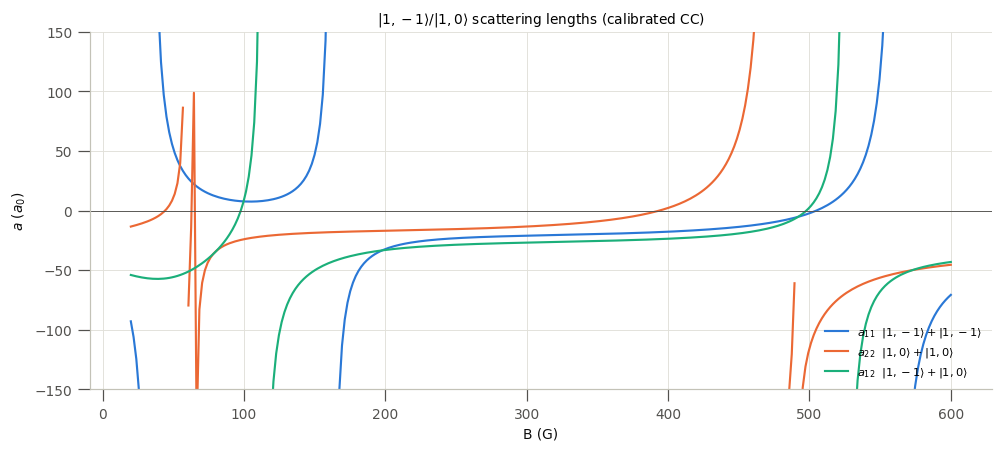

In [15]:
Bs = np.linspace(20, 600, 300)
S1, S2 = (1, -1), (1, 0)
a11 = np.array([cc.scattering_length(S1, S1, float(b)).real for b in Bs])
a22 = np.array([cc.scattering_length(S2, S2, float(b)).real for b in Bs])
a12 = np.array([cc.scattering_length(S1, S2, float(b)).real for b in Bs])

fig, ax = plt.subplots(figsize=(9, 4), layout='constrained')
ax.plot(Bs, mask_poles(a11), color=PAL[0], label=r'$a_{11}$  $|1,-1\rangle+|1,-1\rangle$')
ax.plot(Bs, mask_poles(a22), color=PAL[1], label=r'$a_{22}$  $|1,0\rangle+|1,0\rangle$')
ax.plot(Bs, mask_poles(a12), color=PAL[2], label=r'$a_{12}$  $|1,-1\rangle+|1,0\rangle$')
ax.axhline(0, color=REF, lw=0.6)
ax.set(xlabel='B (G)', ylabel=r'$a$ ($a_0$)', ylim=(-150, 150),
       title=r'$|1,-1\rangle/|1,0\rangle$ scattering lengths (calibrated CC)')
ax.legend(loc='lower right')

rows = []
for B in (40.0, 56.83, 100.0, 150.0, 200.0, 300.0, 400.0, 520.58):
    x11 = cc.scattering_length(S1, S1, B).real; x22 = cc.scattering_length(S2, S2, B).real
    x12 = cc.scattering_length(S1, S2, B).real
    rows.append(dict(B=B, a11=x11, a22=x22, a12=x12, a11_minus_a22=x11 - x22,
                     delta_a=x12 + np.sqrt(x11 * x22) if x11 * x22 > 0 else np.nan,
                     lossy=any(emp.is_lossy(*p, B) for p in ((S1, S1), (S2, S2), (S1, S2)))))
pd.DataFrame(rows).round(2)

## 8. Resonance parameters from the calibrated CC

`kamo.scattering.resonances` finds features in any $a(B)$:
- `locate_pole` finds a pole near a guess.
- `find_features` returns all poles and zeros in a window.
- `characterize` returns the pole strength $a_\mathrm{bg}\Delta$ and the zero crossing; then
  $\Delta=B_\mathrm{zero}-B_0$ and $a_\mathrm{bg}=a_\mathrm{bg}\Delta/\Delta$, Etrych's convention.

Below, each measured resonance is characterised with the calibrated CC and compared with
the measured pole strength and zero crossing.

In [16]:
t0 = time.time()
zc_meas = {(keyof(z.state_a, z.state_b), round(z.B_zero, 1)): z.B_zero for z in kf.ZERO_CROSSINGS}
rows = []
for r in kf.RESONANCES:
    f = lambda B, r=r: cc.scattering_length(r.state_a, r.state_b, B)
    B0 = locate_pole(f, r.B0, half_window=0.4, dB=min(0.05, abs(r.width_theory) / 5))
    # side = sign of Delta (Etrych CC): which side of the pole its own zero lies on
    ch = characterize(f, B0, zero_search=100.0, B_max=999.0, side=np.sign(r.width_theory))
    zm = [z.B_zero for z in kf.ZERO_CROSSINGS if keyof(z.state_a, z.state_b) == r.channel
          and ch.zero_crossing and abs(z.B_zero - ch.zero_crossing) < 3]
    rows.append(dict(channel=r.label, B0_exp=r.B0, B0_cc=round(B0, 3),
                     abgDelta_cc=round(ch.pole_strength, 1), abgDelta_meas=r.pole_strength,
                     abgDelta_etrych_th=round(r.a_bg_theory * r.width_theory, 1),
                     Bzero_cc=None if ch.zero_crossing is None else round(ch.zero_crossing, 2),
                     Bzero_meas=zm[0] if zm else None, Bzero_etrych_th=r.zero_crossing_theory,
                     Delta_cc=None if ch.width is None else round(ch.width, 2),
                     a_bg_cc=None if ch.a_bg is None else round(ch.a_bg, 2)))
print(f"characterised {len(rows)} resonances in {time.time()-t0:.0f} s")
pd.DataFrame(rows)

characterised 17 resonances in 75 s


,channel,B0_exp,B0_cc,abgDelta_cc,abgDelta_meas,abgDelta_etrych_th,Bzero_cc,Bzero_meas,Bzero_etrych_th,Delta_cc,a_bg_cc
0,"|1,+1>+|1,+1>",25.910,25.876,15.4,NaN,15.4,25.41,NaN,NaN,-0.46,-33.22
1,"|1,+1>+|1,+1>",402.740,402.742,1513.7,1530.0,1514.1,350.89,350.4,350.714,-51.86,-29.19
2,"|1,+1>+|1,+1>",752.300,752.287,14.0,NaN,14.0,751.89,NaN,NaN,-0.40,-35.28
3,"|1,+0>+|1,+0>",58.970,58.835,173.7,NaN,194.3,44.24,43.0,NaN,-14.60,-11.90
4,"|1,+0>+|1,+0>",65.570,65.577,140.4,NaN,140.7,63.14,NaN,NaN,-2.44,-57.52
5,"|1,+0>+|1,+0>",472.330,472.313,1992.4,2040.0,1997.5,393.81,393.2,393.635,-78.50,-25.38
6,"|1,+0>+|1,+0>",491.170,491.109,139.5,140.0,139.4,490.11,490.1,489.931,-1.00,-139.73
7,"|1,-1>+|1,-1>",33.582,33.565,-1072.5,-1073.5,-1072.8,NaN,NaN,NaN,NaN,NaN
8,"|1,-1>+|1,-1>",162.360,162.348,711.1,760.0,711.2,NaN,NaN,NaN,NaN,NaN
9,"|1,-1>+|1,-1>",561.140,561.125,1610.3,1660.0,1610.9,504.89,504.9,504.717,-56.23,-28.64


**Zero crossings.** The calibrated CC reproduces pole positions and pole strengths. It also
reproduces the measured zero crossings at 490.1, 504.9 and 43 G. It puts the $|1,+1\rangle$
350.4 G and $|1,0\rangle$ 393.2 G zeros about 0.5 G high. Etrych's MOLSCAT on Tiemann 2020
misses them in the same direction.

With only $(a_S, a_T)$ free, this cannot be fixed: at high field the poles depend almost only
on $a_S$, but the zeros also depend on $a_T$ (next cell). Moving $a_T$ enough to fix 350 G
would spoil the 504.9 G zero and the 1.4 mG-precise 33.582 G pole.

Two explanations are open:
- *model* freedom beyond $a_S$, $a_T$: the $C_6$ / exchange shape;
- *measurement* systematics that affect zeros but not poles: finite collision energy, and the
  dipolar interaction in the 350 G determinations.

In $a$ itself the discrepancy is small, $\lesssim 0.4\,a_0$. Near a zero crossing, where that
matters, use the empirical backend, which is exact at the measured zeros.

In [17]:
rows = []
for z in kf.ZERO_CROSSINGS:
    s = (z.state_a, z.state_b)
    rows.append(dict(channel=lbl(*s).strip('$').replace('\\rangle', '>'), B_zero_meas=z.B_zero, unc=z.B_zero_unc,
                     a_cc_calibrated=round(cc.scattering_length(*s, z.B_zero).real, 3),
                     a_cc_bare=round(cc_bare.scattering_length(*s, z.B_zero).real, 3),
                     a_empirical=round(float(np.real(emp.scattering_length(*s, z.B_zero))), 3),
                     source=z.source))
print("scattering length (a0) at each MEASURED zero-crossing field (ideal: 0)")
pd.DataFrame(rows)

scattering length (a0) at each MEASURED zero-crossing field (ideal: 0)


,channel,B_zero_meas,unc,a_cc_calibrated,a_cc_bare,a_empirical,source
0,"|1,+1>+|1,+1>",350.4,0.1,-0.268,-0.130,0.000,"Fattori 2008 PRL 101,190405"
1,"|1,+0>+|1,+0>",393.2,0.2,-0.198,-0.107,0.000,"Etrych 2023 PRR 5,013174"
2,"|1,+0>+|1,+0>",490.1,0.2,-1.486,39.166,-9.066,"Etrych 2023 PRR 5,013174"
3,"|1,-1>+|1,-1>",504.9,0.2,0.003,0.137,0.000,"Etrych 2023 PRR 5,013174"
4,"|1,+0>+|1,+0>",43.0,2.0,-1.393,-1.360,0.000,"Roy 2013 PRL 111,053202"


## 9. Using the module

For most work, `Potassium39.get_scattering_length(F, mF, B, F2, mF2)` is all you need. By
default it reads the calibrated coupled-channels model **precomputed for all 36 pairs of
ground states** on 1–1000 G, which ships with kamo (`kamo.scattering.tables`,
`data/k39_cc_tables.npz`). The lookup is instant. The tables store $a$ on a grid plus the
poles; interpolation divides the poles out first, so it stays accurate right up to a
resonance. `method="cc"` recomputes directly, `method="empirical"` uses the measured-resonance
model, and `method="kokkelmans"` reads the reference tables on `G:`.

In [18]:
from kamo import Potassium39
from kamo.scattering.tables import table_poles, table_meta
atom = Potassium39()
print("|1,-1>+|1,-1> @ 520.58 G:", round(atom.get_scattering_length(1, -1, 520.58), 3), "a0")
print("|1,-1>+|1,0>  @ 56.83 G: ", round(atom.get_scattering_length(1, -1, 56.83, 1, 0), 3), "a0")
print("|2,0>+|2,0>   @ 100 G:   ", np.round(atom.get_scattering_length(2, 0, 100.0, return_complex=True), 3), "a0 (lossy)")

B = np.linspace(450, 600, 100_000)
t0 = time.time(); a_tab = atom.get_scattering_length(1, -1, B); dt = time.time() - t0
print(f"100k-field sweep from the table: {dt*1e3:.0f} ms")
Bc = B[::5000]
a_dir = np.array([cc.scattering_length((1, -1), (1, -1), float(b)).real for b in Bc])
print(f"table vs direct CC at {len(Bc)} of those fields: max |diff| = {np.abs(a_tab[::5000] - a_dir).max():.1e} a0")
print("poles (B0 + i gamma/2) of |1,1>+|1,-1>:", np.round(table_poles((1, 1), (1, -1)), 4))
try:
    atom.get_scattering_length(2, 0, 100.0, 1, 0, method='empirical')
except ValueError as e:
    print("no data ->", str(e)[:90], "...")
print("table metadata:", {k: table_meta()[k] for k in ('B_valid', 'h', 'a_S', 'a_T', 'created')})

|1,-1>+|1,-1> @ 520.58 G: 10.956 a0
|1,-1>+|1,0>  @ 56.83 G:  -53.211 a0
|2,0>+|2,0>   @ 100 G:    (-30.247-47.702j) a0 (lossy)
100k-field sweep from the table: 8 ms


table vs direct CC at 20 of those fields: max |diff| = 1.5e-05 a0
poles (B0 + i gamma/2) of |1,1>+|1,-1>: [ 77.745 +0.0042j 501.6556+0.0017j 826.4655+0.0051j 833.7908+0.0821j]
no data -> no 'empirical' scattering-length data for |2,+0>+|1,+0>; available: [((1, -1), (1, -1)), ( ...
table metadata: {'B_valid': [1.0, 1000.0], 'h': 0.5, 'a_S': 138.715, 'a_T': -33.3868, 'created': '2026-09-11'}


In [19]:
from kamo.scattering import ScatteringModel, k2_from_scattering_length

m = ScatteringModel(B_max=1000.0)                   # empirical: fast, 6 tabulated channels
print("empirical |1,-1>+|1,-1> @ 150 G:", round(float(m.intra((1, -1), 150.0)), 2), "a0")
print("empirical |1,0>+|1,-1>  @ 100 G:", round(float(m.inter((1, 0), (1, -1), 100.0)), 2), "a0")

mcc = ScatteringModel(B_max=1000.0, backend="cc")   # coupled channels: any channel
a = mcc.intra((2, 0), 100.0)                         # F=2 pairs are lossy -> complex a
print("cc |2,0>+|2,0> @ 100 G:", np.round(a, 3), "a0   is_lossy:", mcc.is_lossy((2, 0), (2, 0), 100.0))
print(f"   -> K2 = {k2_from_scattering_length(a, indistinguishable=True):.2e} m^3/s")
print("measured resonances in |1,0>+|1,-1>:", [(r.B0, r.B0_unc, r.source) for r in m.measured_resonances((1, 0), (1, -1))])
print("zero crossings |1,1>+|1,1>:", m.zero_crossings((1, 1), (1, 1)))

# lower level: the engine itself, a pole finder, and the calibration knobs
c = CoupledChannels(B_max=1000.0)                   # calibrated default
print("a_S, a_T of the calibrated curves (grid):", np.round(c.singlet_triplet_a(), 3))
print("pole near 33.6 G:", round(locate_pole(lambda B: c.scattering_length((1, -1), (1, -1), B), 33.58, 0.3), 4), "G")
# c.set_scattering_lengths(138.80, -33.41)          # retune the walls to any a_S / a_T

empirical |1,-1>+|1,-1> @ 150 G: 50.63 a0
empirical |1,0>+|1,-1>  @ 100 G: 6.25 a0


cc |2,0>+|2,0> @ 100 G: (-30.247-47.702j) a0   is_lossy: True
   -> K2 = 2.07e-16 m^3/s
measured resonances in |1,0>+|1,-1>: [(113.76, 0.01, 'Tanzi 2018 PRA 98,062712'), (526.16, 0.03, 'Etrych 2025 PRX 15,021070')]
zero crossings |1,1>+|1,1>: [350.4]


a_S, a_T of the calibrated curves (grid): [138.709 -33.387]


pole near 33.6 G: 33.5646 G


### Notes and caveats

- **Model content.** The CC is s-wave only, built on Born–Oppenheimer singlet/triplet
  curves with field-dependent hyperfine/Zeeman thresholds. It omits magnetic dipole–dipole
  and second-order spin–orbit couplings. So it has no d/g-wave features, e.g. the $|1,0\rangle$
  60.1 G, $|1,-1\rangle$ 63.6 G and $|2,-2\rangle$ 126 G lines in `HIGHER_PARTIAL_WAVE`. It
  also misses the tiny dipolar $a_\mathrm{im}$ of the $F=1$ states. The 20 mG model
  uncertainty in the fit stands in for these effects.
- **Calibration** fits only $a_S$ and $a_T$; $C_6$ and the curve shapes are Falke's. The
  quoted uncertainties are statistical. The fitted $a_S = 138.715(5)$ sits between
  Falke-B (138.49) and Tiemann 2020 (138.759). It is fitted to *poles*: the 350.4 G and
  393.2 G zero crossings then come out ~0.5 G high, i.e. $a$ is off by ≲0.4 $a_0$ there
  (section 8).
- **Grid.** The calibration is tied to the default radial grid ($h=0.003\,a_0$). Changing the
  grid moves $a_S$ by up to ~0.02 $a_0$, which shifts high-field poles by ~0.05 G;
  recalibrate if you change it.
- **Optical traps.** Zaheer *et al.* (2026) report that 1064 nm trap light shifts the 33.6 G
  and 39.8 G resonances by +85–95 mG per µK of trap depth. Compare free-space theory with
  trap-extrapolated data.
- **Speed.** One CC evaluation takes ~40–90 ms, depending on the channel count in the $M_F$
  block. Use the empirical backend for dense sweeps of the six tabulated channels.